In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/mSHIFT_SHeS/code_ocean/

/content/drive/MyDrive/mSHIFT_SHeS/code_ocean


This notebook contains the code that produces the plots for each indicator and demographic group. The formatting parameters for each plot can be found and edited in plot_indicator_dict.json

In [ ]:
import pandas as pd
import numpy as np
import json
import dill
import os
import sys
from pathlib import Path

data_path = Path("data")
results_path = Path("results")

In [ ]:
# Add the parent directory of the notebook to sys.path, enables module imports from notebook_code
sys.path.append(str(Path().resolve() / 'code/notebooks/notebook_code'))

In [ ]:
import plotting
from plotting import plot_change_impact

In [ ]:
with open(data_path / "mappings/plot_indicator_dict.json", encoding="utf-8-sig") as json_file:
    plot_indicator_dict = json.load(json_file)

with open(data_path / "mappings/nutrient_label_dict.json") as json_file:
    nutrient_label_dict = json.load(json_file)

mean_env_columns = np.loadtxt(data_path / 'indicator_lists/mean_env_columns.txt', dtype = str).tolist()

In [ ]:
df_baseline = pd.read_parquet(data_path / 'df_baseline.parquet')

In [ ]:
plot_indicator_dict['median_Eut']['Overall']['y_lim'] = [12, 18]
plot_indicator_dict['median_GHG']['Overall']['y_lim'] = [3, 5]
plot_indicator_dict['median_Land']['Overall']['y_lim'] = [4, 6.5]
plot_indicator_dict['Selenium']['Overall']['y_lim'] = [34, 50]
plot_indicator_dict['Zincmg']['Overall']['y_lim'] = [6, 8.5]

In [ ]:
import importlib

In [ ]:
importlib.reload(plotting)
from plotting import plot_change_impact

Baseline value: 887.56
CCC20, No replacement: -0.29 (-0.6, 0.03), percent change: -3.22780531771068
CCC35, No replacement: -0.41 (-0.72, -0.1), percent change: -4.645110410094637
HC70, No replacement: -0.25 (-0.56, 0.07), percent change: -2.7839116719242907
HC60, No replacement: -0.28 (-0.59, 0.04), percent change: -3.1297881928796754
HC31, No replacement: -0.41 (-0.72, -0.09), percent change: -4.5741324921135655
CCC20, Pulses and legumes: -0.1 (-0.42, 0.21), percent change: -1.1694456962595765
CCC35, Pulses and legumes: -0.16 (-0.48, 0.15), percent change: -1.8228931951329428
HC70, Pulses and legumes: -0.08 (-0.4, 0.23), percent change: -0.9260928346101849
HC60, Pulses and legumes: -0.1 (-0.41, 0.22), percent change: -1.0838215412347905
HC31, Pulses and legumes: -0.15 (-0.47, 0.16), percent change: -1.7440288418206398
CCC20, Vegetables: -0.1 (-0.42, 0.21), percent change: -1.172825597115818
CCC35, Vegetables: -0.16 (-0.48, 0.15), percent change: -1.8307796304641732
HC70, Vegetables: -

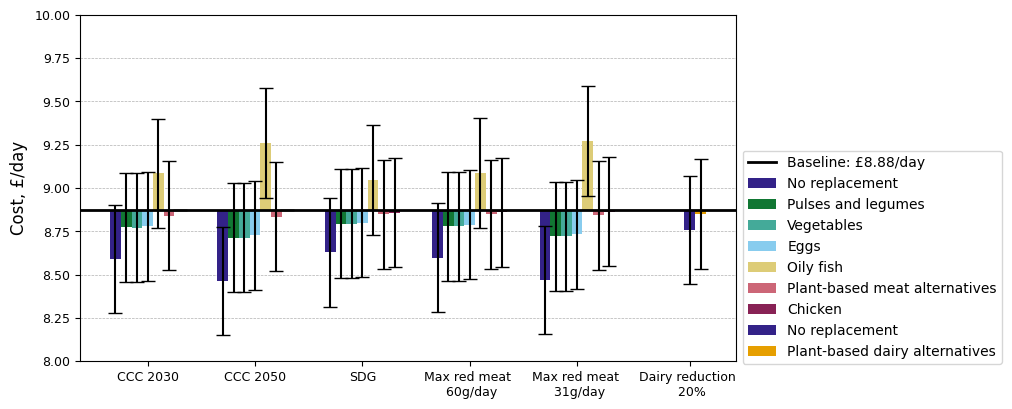

In [ ]:
dem_group = 'Overall'
indicator = 'median_price_sim'
path_to_results = results_path / "Output/Scenarios/"
save_path = results_path / "Plots/nutrients + impacts/"
save_path.mkdir(parents=True, exist_ok=True)

save_fig = True

plot_change_impact( indicator=indicator,
                    dem_group=dem_group,
                    path_to_results=path_to_results,
                    save_path = save_path,
                    nutrient_label_dict=nutrient_label_dict,
                    plot_indicator_dict= plot_indicator_dict,
                    mean_env_columns = mean_env_columns,
                    title_pad=0,
                    legend_position=(1, 0.3),
                    save_fig=save_fig)

In [ ]:
importlib.reload(plotting)
from plotting import plot_change_impact

In [ ]:
### Creates an editable pdf of the plots rather than a png ####


from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import string

dem_group = 'Overall'

indicators_list = ['Proteing', 'Calciummg', 'Iodine', 'Selenium', 'Zincmg']
#indicators_list = ['median_GHG', 'median_Land', 'median_WaterUse', 'median_Eut']

path_to_results = results_path / "Output/Scenarios/"
save_path = results_path / "Plots/nutrients + impacts/"
save_path.mkdir(parents=True, exist_ok=True)


pdf_filename = save_path / "Figure2.pdf"

with PdfPages(pdf_filename) as pdf:

    for i, indicator in enumerate(indicators_list):

        plot_change_impact(
            indicator=indicator,
            dem_group=dem_group,
            path_to_results=path_to_results,
            save_path=save_path,
            nutrient_label_dict=nutrient_label_dict,
            plot_indicator_dict=plot_indicator_dict,
            mean_env_columns=mean_env_columns,
            title_pad=0,
            legend_position=(1, 0.3),
            save_fig=False
        )

        fig = plt.gcf()
        ax = plt.gca()

        letter = string.ascii_uppercase[i]

        ax.set_title(f"({letter})", loc='left', fontweight='bold', fontsize=9)
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

Baseline value: 67.2
CCC20, No replacement: -6.77 (-8.69, -4.85), percent change: -10.074404761904761
CCC35, No replacement: -9.85 (-11.73, -7.97), percent change: -14.657738095238093
HC70, No replacement: -5.61 (-7.53, -3.69), percent change: -8.348214285714285
HC60, No replacement: -6.29 (-8.21, -4.37), percent change: -9.360119047619047
HC31, No replacement: -9.09 (-11.01, -7.17), percent change: -13.526785714285714
CCC20, Pulses and legumes: -5.24 (-7.18, -3.3), percent change: -7.7976190476190474
CCC35, Pulses and legumes: -7.67 (-9.57, -5.77), percent change: -11.413690476190476
HC70, Pulses and legumes: -4.25 (-6.19, -2.31), percent change: -6.324404761904762
HC60, Pulses and legumes: -4.76 (-6.7, -2.82), percent change: -7.083333333333333
HC31, Pulses and legumes: -6.9 (-8.82, -4.98), percent change: -10.267857142857142
CCC20, Vegetables: -5.79 (-7.73, -3.85), percent change: -8.616071428571429
CCC35, Vegetables: -8.63 (-10.53, -6.73), percent change: -12.842261904761907
HC70, 